# 08 — Long-Only Performance Attribution (2019–2024)

## Purpose

Deep ex-post performance attribution for the **All6-EW + TO\_MVO** strategy
on the true holdout period (2019-01 to 2024-09), benchmarked against EEM.

Inspired by Bekaert's performance measurement framework:
- Sharpe Ratio, Treynor Measure, Jensen's Alpha, Appraisal Ratio
- Return-based style analysis (Sharpe 1992)
- Rolling exposure, tracking error, and active return stability

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import rankdata

from src.data_loader import load_signal_data, FACTOR_COLUMNS, INDUSTRIES, COUNTRY_TC_BPS, DEFAULT_TC_BPS

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')
REALISTIC_TC_BPS = 45.0

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))
def ann_ret(s): return s.dropna().mean() * 12
def ann_vol(s): return s.dropna().std() * np.sqrt(12)
def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())

# Load data
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)
pc_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_all_portfolio_returns.csv', index_col=0, parse_dates=True)
ind_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/composite_all6_ew_industry_returns.csv', index_col=0, parse_dates=True)

COL_A = 'TO_MVO_All6EW_LW_60m'

# EEM
eem_raw = pd.read_csv('../data/eem_returns_monthly.csv', index_col=0, parse_dates=True)
eem_raw['mret'] = pd.to_numeric(eem_raw['mret'], errors='coerce')
eem_raw = eem_raw.dropna(subset=['mret'])
eem_raw.index = eem_raw.index.to_period('M').to_timestamp()
eem_ret = eem_raw['mret'].sort_index()
eem_ret = eem_ret[~eem_ret.index.duplicated(keep='last')]

# Turnover
stock_to_df = pd.read_csv(f'{OUTPUT_DIR}/csv/exp3b_turnovers.csv', index_col=0)
stock_to = stock_to_df.loc['All6-EW', 'avg_monthly_turnover']
mc_scores = pd.read_csv(f'{OUTPUT_DIR}/csv/exp4_multicriteria_scores.csv')
pc_to_mvo = 0.007
for _, row in mc_scores.iterrows():
    if 'All6EW' in row['Strategy'] and row['PC'] == 'TO_MVO':
        pc_to_mvo = row['PC_TO']
total_to = stock_to + pc_to_mvo
TC = total_to * (REALISTIC_TC_BPS / 10_000)

# Holdout
strat = pc_ret[COL_A].dropna()
common = strat.index.intersection(eem_ret.index)
holdout = sorted([d for d in common if d >= HOLD_START])
s_h = strat.reindex(holdout)
eem_h = eem_ret.reindex(holdout)

print(f'Holdout: {len(holdout)} months ({holdout[0].strftime("%Y-%m")} to {holdout[-1].strftime("%Y-%m")})')
print(f'Turnover: {total_to:.3f}/mo, TC drag: {TC*12:.2%}/yr')

Holdout: 69 months (2019-01 to 2024-09)
Turnover: 0.192/mo, TC drag: 1.03%/yr


## 1. Standard Performance Measures

Following Bekaert's framework, we compute all four classical measures
using EEM as the market portfolio. Risk-free rate is approximated as zero
(a common simplification for relative comparisons over the same period).

| Measure | Formula | Interpretation |
|---------|---------|----------------|
| Sharpe | \(\frac{\bar{r}_p}{\sigma_p}\) | Excess return per unit of total risk |
| Treynor | \(\frac{\bar{r}_p}{\beta_p}\) | Excess return per unit of systematic risk |
| Jensen's \(\alpha\) | \(\bar{r}_p - \beta_p \bar{r}_m\) | Active return after adjusting for market exposure |
| Appraisal Ratio | \(\frac{\alpha_p}{s_p}\) | Alpha per unit of idiosyncratic risk |

In [2]:
# Market model regression: r_p = alpha + beta * r_m + eps
slope, intercept, r_value, p_value, std_err = stats.linregress(eem_h.values, s_h.values)
beta_full = slope
alpha_monthly = intercept
r_sq = r_value**2

residuals = s_h.values - (alpha_monthly + beta_full * eem_h.values)
s_p = np.std(residuals, ddof=1) * np.sqrt(12)  # annualized idiosyncratic vol
alpha_ann = alpha_monthly * 12
appraisal_ratio = alpha_ann / s_p if s_p > 0 else np.nan

treynor = (s_h.mean() * 12) / beta_full if beta_full != 0 else np.nan
sharpe = ann_sharpe(s_h)

print('='*70)
print('STANDARD PERFORMANCE MEASURES: All6-EW + TO_MVO (Holdout)')
print('='*70)
print(f'  Benchmark: EEM (iShares MSCI EM ETF, total return)')
print(f'  Period: {holdout[0].strftime("%Y-%m")} to {holdout[-1].strftime("%Y-%m")} ({len(holdout)} months)')
print()
print(f'  1. Sharpe Ratio:       {sharpe:.3f}')
print(f'  2. Treynor Measure:    {treynor:.4f} ({treynor*100:.2f}%)')
print(f'  3. Jensen\'s Alpha:    {alpha_ann:.2%}/yr (t-stat={alpha_monthly/std_err:.2f}, p={p_value:.3f})')
print(f'  4. Appraisal Ratio:    {appraisal_ratio:.3f}')
print()
print(f'  Market Model Regression:')
print(f'    r_p = {alpha_monthly:.4f} + {beta_full:.3f} × r_EEM + ε')
print(f'    Beta:                {beta_full:.3f}')
print(f'    R²:                  {r_sq:.3f} ({r_sq*100:.1f}% of variance explained by EEM)')
print(f'    Idiosyncratic Vol:   {s_p:.2%} (annualized)')
print(f'    Total Vol:           {ann_vol(s_h):.2%}')
print(f'    Systematic Vol:      {beta_full * ann_vol(eem_h):.2%}')

# Net versions
s_h_net = s_h - TC
slope_n, intercept_n, r_n, p_n, se_n = stats.linregress(eem_h.values, s_h_net.values)
print(f'\n  After TC ({REALISTIC_TC_BPS:.0f}bp):')
print(f'    Jensen\'s Alpha (net): {intercept_n*12:.2%}/yr')
print(f'    Sharpe (net):          {ann_sharpe(s_h_net):.3f}')

# Comparison with EEM
print(f'\n  EEM Benchmark:')
print(f'    Sharpe:              {ann_sharpe(eem_h):.3f}')
print(f'    Ann Return:          {ann_ret(eem_h):.2%}')

STANDARD PERFORMANCE MEASURES: All6-EW + TO_MVO (Holdout)
  Benchmark: EEM (iShares MSCI EM ETF, total return)
  Period: 2019-01 to 2024-09 (69 months)

  1. Sharpe Ratio:       0.607
  2. Treynor Measure:    0.1194 (11.94%)
  3. Jensen's Alpha:    5.17%/yr (t-stat=0.10, p=0.000)
  4. Appraisal Ratio:    0.798

  Market Model Regression:
    r_p = 0.0043 + 0.963 × r_EEM + ε
    Beta:                0.963
    R²:                  0.883 (88.3% of variance explained by EEM)
    Idiosyncratic Vol:   6.47% (annualized)
    Total Vol:           18.95%
    Systematic Vol:      17.81%

  After TC (45bp):
    Jensen's Alpha (net): 4.13%/yr
    Sharpe (net):          0.552

  EEM Benchmark:
    Sharpe:              0.356
    Ann Return:          6.58%


## 2. Rolling Beta to EEM

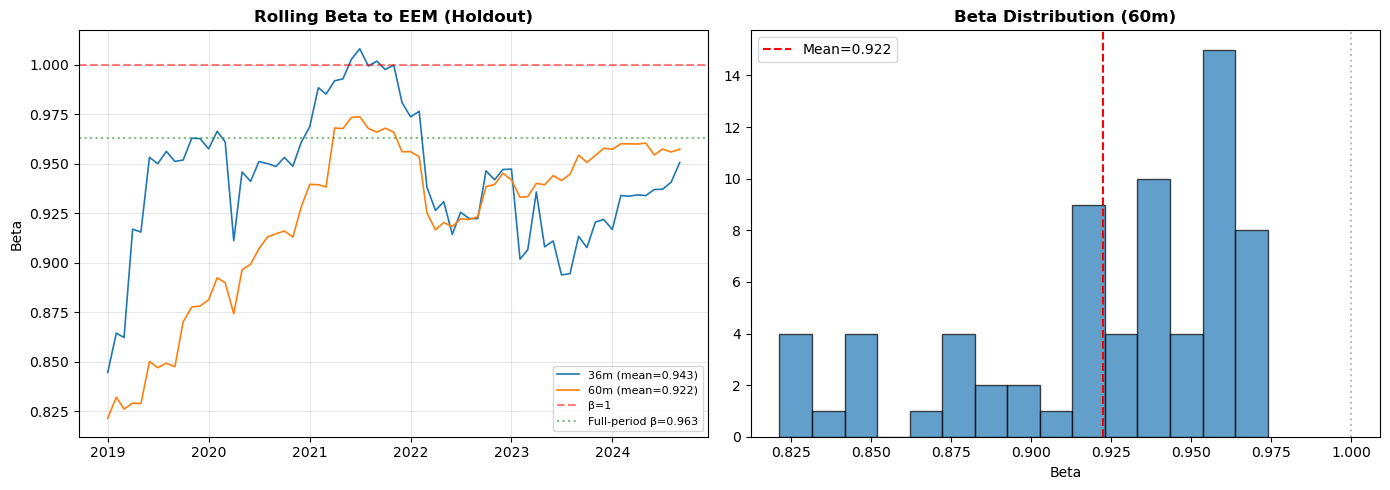

Rolling Beta Summary (Holdout):
  36m: mean=0.943, std=0.034, range=[0.845, 1.008]
  60m: mean=0.922, std=0.042, range=[0.821, 0.974]
  Beta is stable over time.


In [3]:
from src.residual_returns import estimate_rolling_beta

beta_36 = estimate_rolling_beta(strat, eem_ret, window=36, min_obs=18)
beta_60 = estimate_rolling_beta(strat, eem_ret, window=60, min_obs=24)

b36_h = beta_36[beta_36.index >= HOLD_START].dropna()
b60_h = beta_60[beta_60.index >= HOLD_START].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
if len(b36_h) > 0:
    ax.plot(b36_h.index, b36_h.values, lw=1.2, label=f'36m (mean={b36_h.mean():.3f})')
if len(b60_h) > 0:
    ax.plot(b60_h.index, b60_h.values, lw=1.2, label=f'60m (mean={b60_h.mean():.3f})')
ax.axhline(y=1, color='red', ls='--', alpha=0.5, label='β=1')
ax.axhline(y=beta_full, color='green', ls=':', alpha=0.5, label=f'Full-period β={beta_full:.3f}')
ax.set_title('Rolling Beta to EEM (Holdout)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Beta')

ax = axes[1]
if len(b60_h) > 0:
    ax.hist(b60_h.values, bins=15, alpha=0.7, edgecolor='black')
    ax.axvline(x=b60_h.mean(), color='red', ls='--', label=f'Mean={b60_h.mean():.3f}')
    ax.axvline(x=1, color='gray', ls=':', alpha=0.5)
    ax.set_title('Beta Distribution (60m)', fontweight='bold')
    ax.legend(); ax.set_xlabel('Beta')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb08_rolling_beta.pdf', bbox_inches='tight')
plt.show()

print(f'Rolling Beta Summary (Holdout):')
if len(b36_h) > 0:
    print(f'  36m: mean={b36_h.mean():.3f}, std={b36_h.std():.3f}, range=[{b36_h.min():.3f}, {b36_h.max():.3f}]')
if len(b60_h) > 0:
    print(f'  60m: mean={b60_h.mean():.3f}, std={b60_h.std():.3f}, range=[{b60_h.min():.3f}, {b60_h.max():.3f}]')
print(f'  Beta is {"stable" if (b60_h.std() if len(b60_h)>0 else b36_h.std()) < 0.05 else "moderately varying"} over time.')

## 3. Industry Exposure Over Time

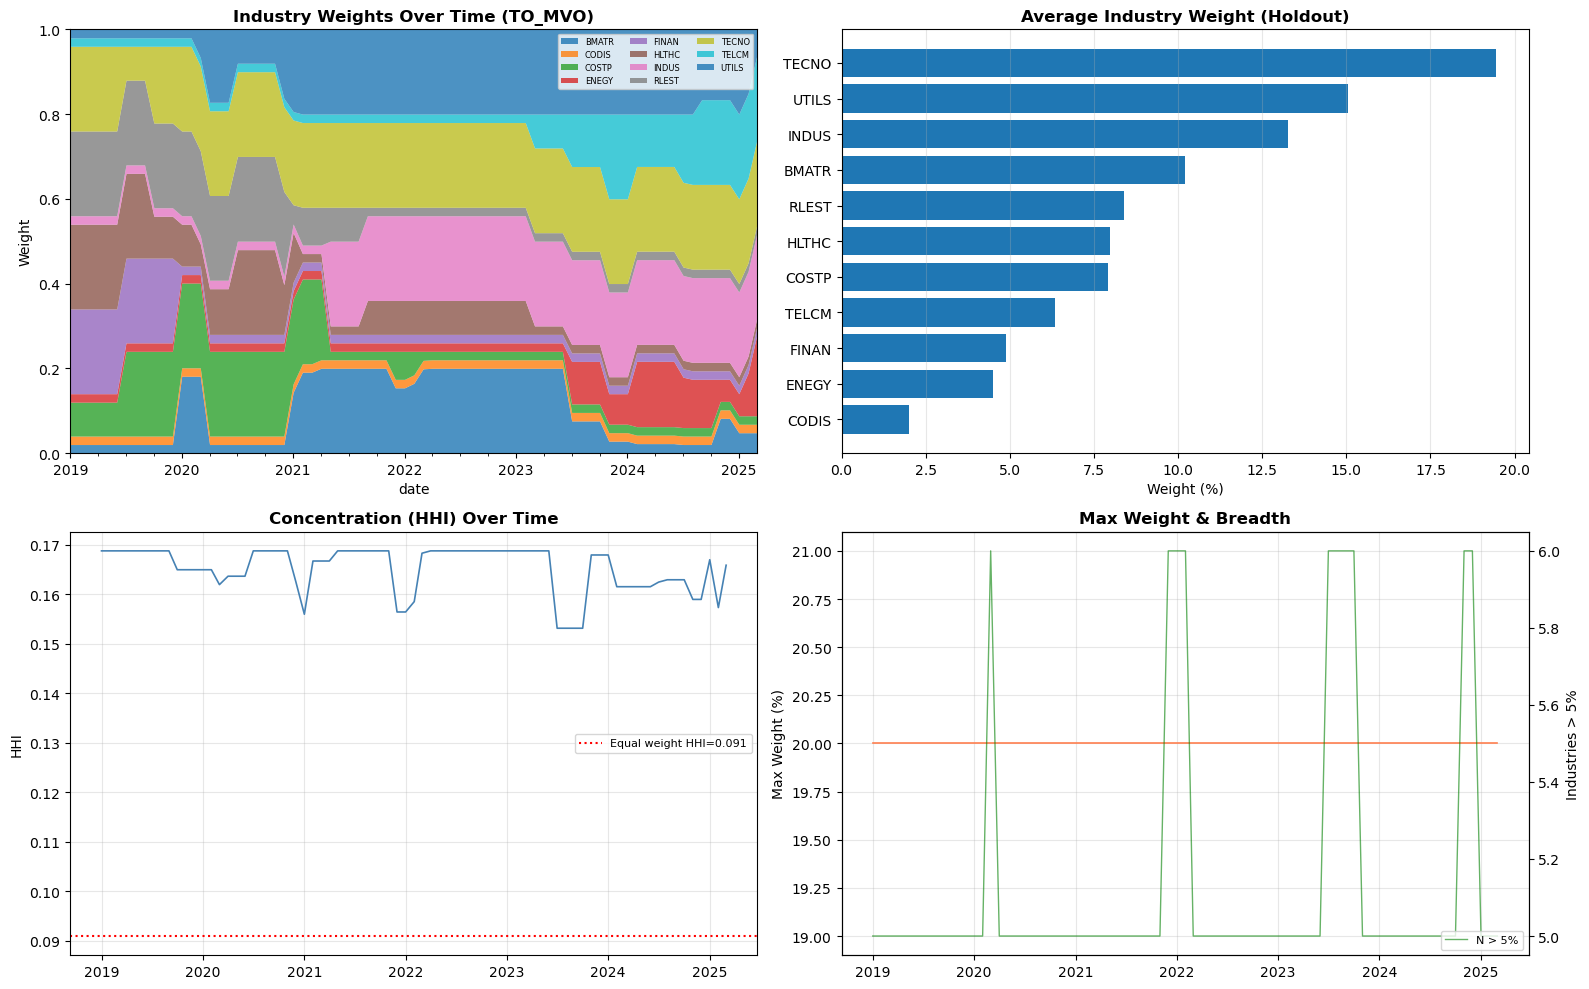

Industry Exposure Summary (Holdout):
  Average HHI: 0.1653 (equal-weight=0.0909)
  Max single-industry weight: 20.0%
  Top 3 industries by avg weight: INDUS, UTILS, TECNO


In [4]:
# Reconstruct TO_MVO industry weights over holdout
from src.portfolio_construction import turnover_penalized as to_mvo_func
from sklearn.covariance import LedoitWolf
import pandas as pd

# Use composite industry returns to compute TO_MVO weights month by month
ind_ret_full = ind_ret.copy()
ind_ret_full.index = pd.to_datetime(ind_ret_full.index)

weight_records = []
prev_w = np.ones(len(INDUSTRIES)) / len(INDUSTRIES)
sorted_dates = sorted(ind_ret_full.index)

for i, dt in enumerate(sorted_dates):
    if dt < pd.Timestamp('2014-01-01'):
        continue
    start_idx = max(0, i - 60)
    hist = ind_ret_full.iloc[start_idx:i]
    if len(hist) < 24:
        weight_records.append({'date': dt, **{ind: 1/len(INDUSTRIES) for ind in INDUSTRIES}})
        continue
    
    try:
        cov = LedoitWolf().fit(hist.values).covariance_
        mu = hist.mean().values
        w = to_mvo_func(hist, cov_matrix=cov, mean_returns=mu, prev_weights=prev_w)
        if len(w) == len(INDUSTRIES):
            prev_w = w
            weight_records.append({'date': dt, **{ind: w[j] for j, ind in enumerate(INDUSTRIES)}})
        else:
            weight_records.append({'date': dt, **{ind: 1/len(INDUSTRIES) for ind in INDUSTRIES}})
    except Exception:
        weight_records.append({'date': dt, **{ind: 1/len(INDUSTRIES) for ind in INDUSTRIES}})

weights_df = pd.DataFrame(weight_records).set_index('date')
weights_h = weights_df[weights_df.index >= HOLD_START]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Stacked area
ax = axes[0, 0]
weights_h.plot.area(ax=ax, linewidth=0, alpha=0.8)
ax.set_title('Industry Weights Over Time (TO_MVO)', fontweight='bold')
ax.set_ylabel('Weight'); ax.legend(fontsize=6, ncol=3, loc='upper right')
ax.set_ylim(0, 1)

# Average weights bar
ax = axes[0, 1]
avg_w = weights_h.mean().sort_values(ascending=True)
ax.barh(avg_w.index, avg_w.values*100)
ax.set_title('Average Industry Weight (Holdout)', fontweight='bold')
ax.set_xlabel('Weight (%)'); ax.grid(True, alpha=0.3, axis='x')

# HHI concentration
ax = axes[1, 0]
hhi = (weights_h**2).sum(axis=1)
ax.plot(hhi.index, hhi.values, lw=1.2, color='steelblue')
ax.axhline(y=1/len(INDUSTRIES), color='red', ls=':', label=f'Equal weight HHI={1/len(INDUSTRIES):.3f}')
ax.set_title('Concentration (HHI) Over Time', fontweight='bold')
ax.set_ylabel('HHI'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Max weight
ax = axes[1, 1]
max_w = weights_h.max(axis=1)
ax.plot(max_w.index, max_w.values*100, lw=1.2, color='coral')
n_above5 = (weights_h > 0.05).sum(axis=1)
ax2 = ax.twinx()
ax2.plot(n_above5.index, n_above5.values, lw=1, color='green', alpha=0.6, label='N > 5%')
ax.set_title('Max Weight & Breadth', fontweight='bold')
ax.set_ylabel('Max Weight (%)'); ax2.set_ylabel('Industries > 5%')
ax2.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb08_industry_exposure.pdf', bbox_inches='tight')
plt.show()

print(f'Industry Exposure Summary (Holdout):')
print(f'  Average HHI: {hhi.mean():.4f} (equal-weight={1/len(INDUSTRIES):.4f})')
print(f'  Max single-industry weight: {weights_h.max().max():.1%}')
print(f'  Top 3 industries by avg weight: {", ".join(avg_w.tail(3).index.tolist())}')

## 4. Country Exposure Over Time

  Dropped 12 duplicate (ric, ym) rows
Signal data loaded: 98,742 rows x 51 cols | 2004-01 to 2025-03


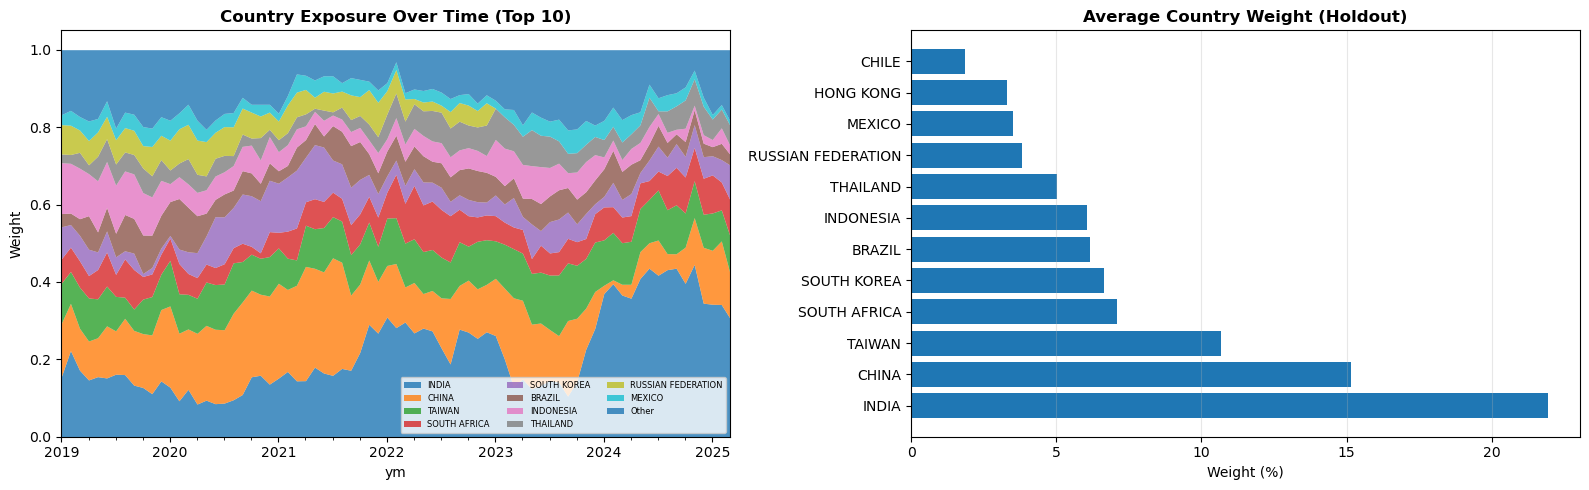

Top Country Exposures (Holdout Avg):
  INDIA                    : 21.95%
  CHINA                    : 15.14%
  TAIWAN                   : 10.66%
  SOUTH AFRICA             : 7.08%
  SOUTH KOREA              : 6.63%
  BRAZIL                   : 6.15%
  INDONESIA                : 6.05%
  THAILAND                 : 5.01%
  RUSSIAN FEDERATION       : 3.82%
  MEXICO                   : 3.52%


In [5]:
df = load_signal_data('../data')
df = df.sort_values(['ym', 'ric'])
ret_col = 'mret_bbg'
df_oos = df[df['ym'] >= '2009-02'].copy()

# Reconstruct holdings
all_holdings = []
for ym in sorted(df_oos['ym'].unique()):
    month_df = df_oos[df_oos['ym'] == ym].copy()
    for ind in INDUSTRIES:
        ind_df = month_df[month_df['industry'] == ind].copy()
        if len(ind_df) < 5:
            continue
        valid_factors = [f for f in FACTOR_COLUMNS if ind_df[f].notna().sum() >= 5]
        if not valid_factors:
            continue
        for f in valid_factors:
            ind_df[f'{f}_rank'] = rankdata(ind_df[f].fillna(ind_df[f].median()))
        ind_df['composite'] = sum(ind_df[f'{f}_rank'] for f in valid_factors) / len(valid_factors)
        n = len(ind_df)
        top_frac = 0.2 if n >= 15 else 0.33
        cutoff = ind_df['composite'].quantile(1 - top_frac)
        selected = ind_df[ind_df['composite'] >= cutoff]
        if len(selected) == 0:
            continue
        wt = 1.0 / (len(selected) * len(INDUSTRIES))
        for _, row in selected.iterrows():
            all_holdings.append({
                'ym': ym, 'ric': row['ric'], 'country': row.get('country','Unknown'),
                'industry': ind, 'weight': wt,
            })

holdings = pd.DataFrame(all_holdings)
hold_h = holdings[holdings['ym'] >= HOLD_START.strftime('%Y-%m')].copy()

# Country weights over time
country_wt = hold_h.groupby(['ym','country'])['weight'].sum().unstack(fill_value=0)
country_wt.index = pd.to_datetime(country_wt.index)

# Top countries by average weight
avg_cw = country_wt.mean().sort_values(ascending=False)
top_countries = avg_cw.head(10).index.tolist()
other = country_wt.drop(columns=top_countries, errors='ignore').sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
plot_df = country_wt[top_countries].copy()
plot_df['Other'] = other
plot_df.plot.area(ax=ax, linewidth=0, alpha=0.8)
ax.set_title('Country Exposure Over Time (Top 10)', fontweight='bold')
ax.set_ylabel('Weight'); ax.legend(fontsize=6, ncol=3)

ax = axes[1]
ax.barh(avg_cw.head(12).index, avg_cw.head(12).values*100)
ax.set_title('Average Country Weight (Holdout)', fontweight='bold')
ax.set_xlabel('Weight (%)'); ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb08_country_exposure.pdf', bbox_inches='tight')
plt.show()

print('Top Country Exposures (Holdout Avg):')
for c in avg_cw.head(10).index:
    print(f'  {c:25s}: {avg_cw[c]:.2%}')

## 5. Monthly Alpha & Cumulative Active Return

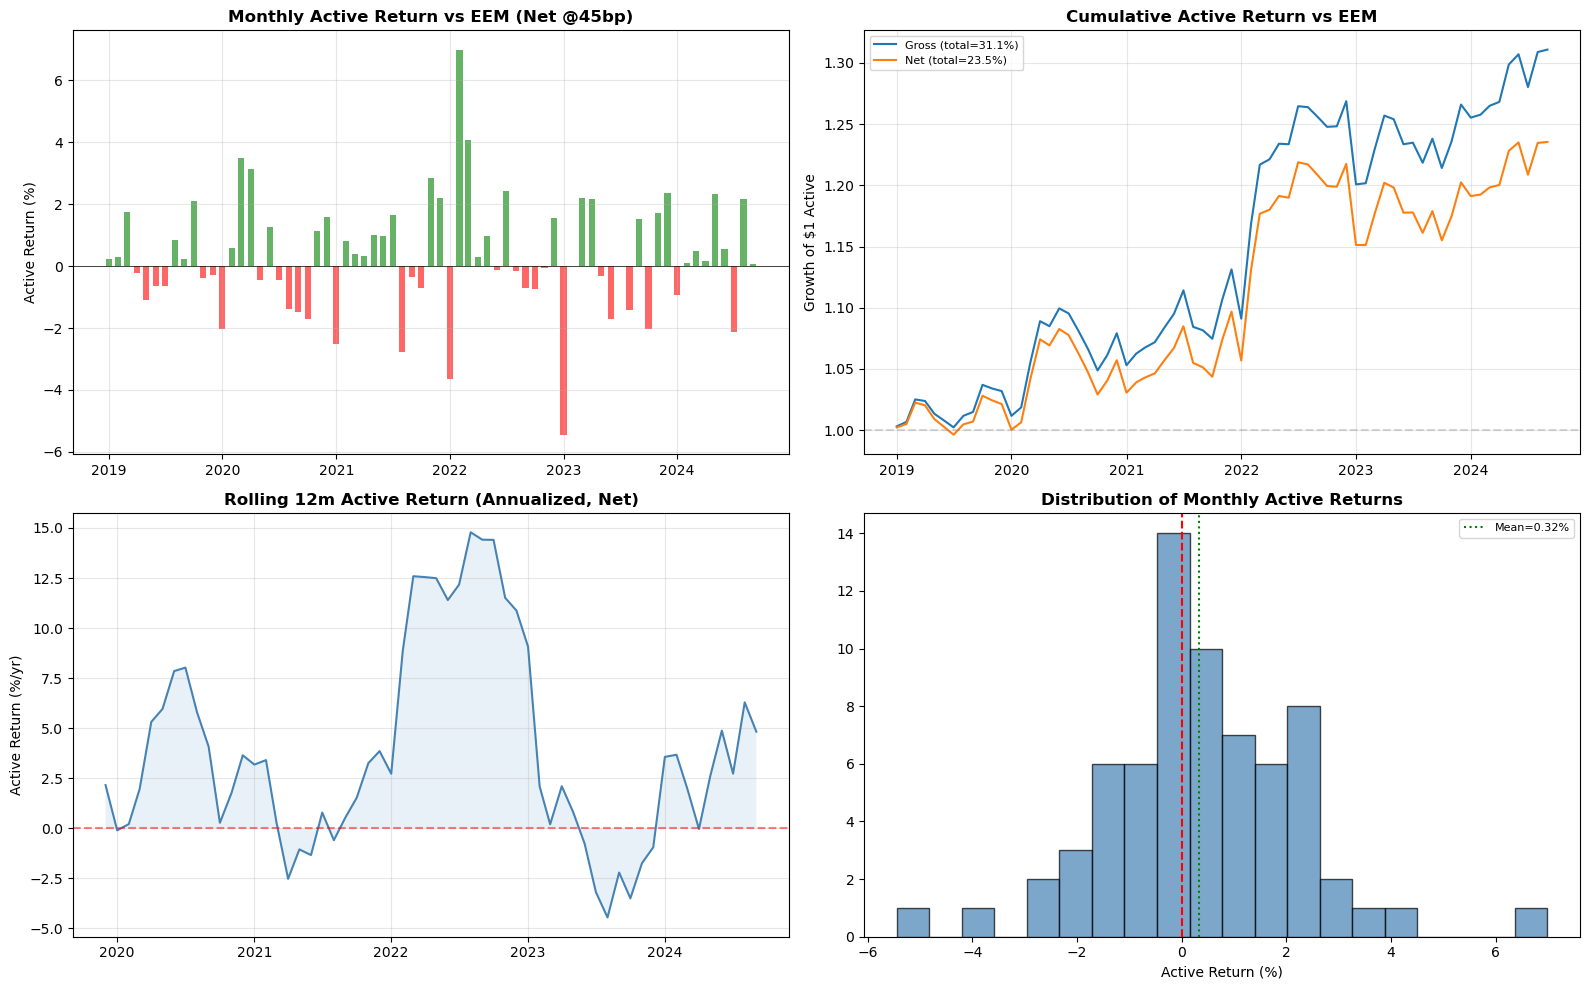

Active Return Summary (Net @45bp):
  Mean monthly: 0.32% (3.89% ann.)
  Hit rate: 56.5% positive months
  Skewness: 0.22
  Kurtosis: 2.25


In [6]:
excess = s_h - eem_h  # active return (gross)
excess_net = s_h - TC - eem_h

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Monthly alpha bars
ax = axes[0, 0]
colors = ['green' if x > 0 else 'red' for x in excess_net.values]
ax.bar(excess_net.index, excess_net.values * 100, color=colors, alpha=0.6, width=20)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('Monthly Active Return vs EEM (Net @45bp)', fontweight='bold')
ax.set_ylabel('Active Return (%)'); ax.grid(True, alpha=0.3)

# Cumulative active return
ax = axes[0, 1]
cum_active_g = (1 + excess).cumprod()
cum_active_n = (1 + excess_net).cumprod()
ax.plot(cum_active_g.index, cum_active_g.values, lw=1.5, label=f'Gross (total={cum_active_g.iloc[-1]-1:.1%})')
ax.plot(cum_active_n.index, cum_active_n.values, lw=1.5, label=f'Net (total={cum_active_n.iloc[-1]-1:.1%})')
ax.axhline(y=1, color='gray', ls='--', alpha=0.3)
ax.set_title('Cumulative Active Return vs EEM', fontweight='bold')
ax.set_ylabel('Growth of $1 Active'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Rolling 12m alpha
ax = axes[1, 0]
roll_alpha = excess_net.rolling(12).mean() * 12
ax.plot(roll_alpha.index, roll_alpha.values*100, lw=1.5, color='steelblue')
ax.axhline(y=0, color='red', ls='--', alpha=0.5)
ax.fill_between(roll_alpha.index, roll_alpha.values*100, 0, alpha=0.1)
ax.set_title('Rolling 12m Active Return (Annualized, Net)', fontweight='bold')
ax.set_ylabel('Active Return (%/yr)'); ax.grid(True, alpha=0.3)

# Distribution
ax = axes[1, 1]
ax.hist(excess_net.values*100, bins=20, alpha=0.7, edgecolor='black', color='steelblue')
ax.axvline(x=0, color='red', ls='--')
ax.axvline(x=excess_net.mean()*100, color='green', ls=':', label=f'Mean={excess_net.mean()*100:.2f}%')
ax.set_title('Distribution of Monthly Active Returns', fontweight='bold')
ax.set_xlabel('Active Return (%)'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb08_alpha_analysis.pdf', bbox_inches='tight')
plt.show()

print(f'Active Return Summary (Net @45bp):')
print(f'  Mean monthly: {excess_net.mean()*100:.2f}% ({excess_net.mean()*12:.2%} ann.)')
print(f'  Hit rate: {(excess_net>0).mean():.1%} positive months')
print(f'  Skewness: {excess_net.skew():.2f}')
print(f'  Kurtosis: {excess_net.kurtosis():.2f}')

## 6. Tracking Error Analysis

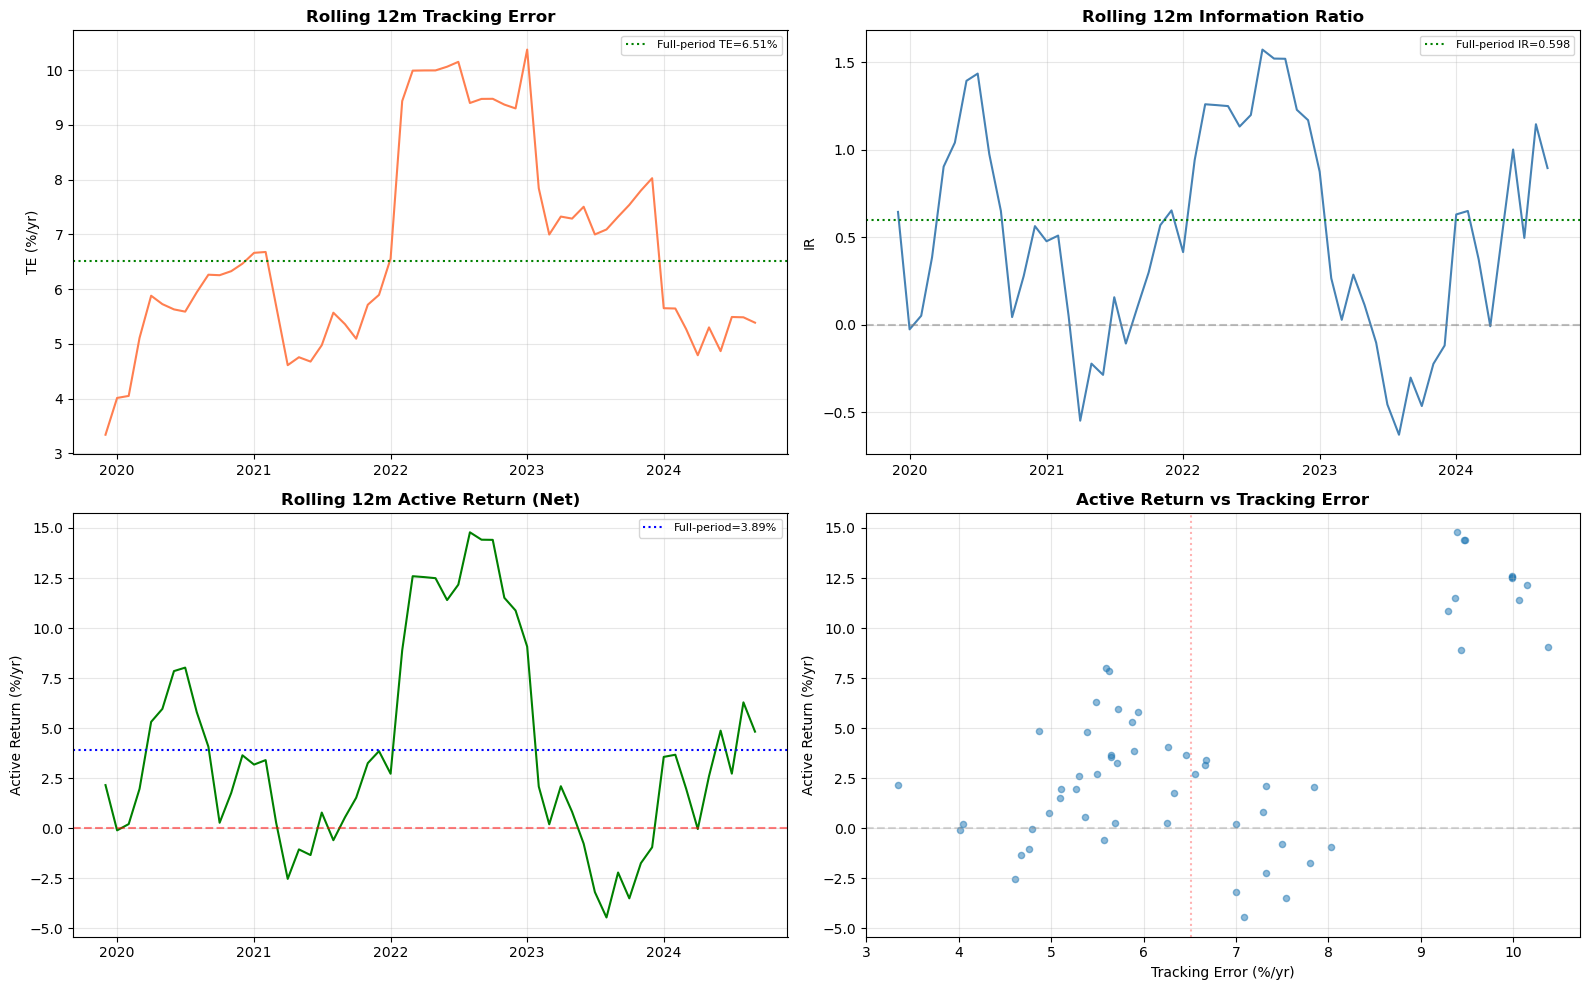

Tracking Error Analysis (Net @45bp):
  Full-period TE: 6.51%
  Full-period IR: 0.598
  TE range (12m rolling): [3.34%, 10.37%]
  TE is stable


In [7]:
te_full = excess_net.std() * np.sqrt(12)
ir_full = excess_net.mean() * 12 / te_full

# Rolling TE
roll_te = excess_net.rolling(12).std() * np.sqrt(12)
roll_ir = excess_net.rolling(12).apply(lambda x: x.mean()*12/(x.std()*np.sqrt(12)) if x.std()>0 else 0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(roll_te.index, roll_te.values*100, lw=1.5, color='coral')
ax.axhline(y=te_full*100, color='green', ls=':', label=f'Full-period TE={te_full:.2%}')
ax.set_title('Rolling 12m Tracking Error', fontweight='bold')
ax.set_ylabel('TE (%/yr)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(roll_ir.index, roll_ir.values, lw=1.5, color='steelblue')
ax.axhline(y=0, color='gray', ls='--', alpha=0.5)
ax.axhline(y=ir_full, color='green', ls=':', label=f'Full-period IR={ir_full:.3f}')
ax.set_title('Rolling 12m Information Ratio', fontweight='bold')
ax.set_ylabel('IR'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Active return stability
ax = axes[1, 0]
roll_active = excess_net.rolling(12).mean() * 12
ax.plot(roll_active.index, roll_active.values*100, lw=1.5, color='green')
ax.axhline(y=0, color='red', ls='--', alpha=0.5)
ax.axhline(y=excess_net.mean()*12*100, color='blue', ls=':', label=f'Full-period={excess_net.mean()*12:.2%}')
ax.set_title('Rolling 12m Active Return (Net)', fontweight='bold')
ax.set_ylabel('Active Return (%/yr)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Dual: active return vs TE
ax = axes[1, 1]
ax.scatter(roll_te.values*100, roll_active.values*100, alpha=0.5, s=20)
ax.axhline(y=0, color='gray', ls='--', alpha=0.3)
ax.axvline(x=te_full*100, color='red', ls=':', alpha=0.3)
ax.set_xlabel('Tracking Error (%/yr)')
ax.set_ylabel('Active Return (%/yr)')
ax.set_title('Active Return vs Tracking Error', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb08_tracking_error.pdf', bbox_inches='tight')
plt.show()

print(f'Tracking Error Analysis (Net @45bp):')
print(f'  Full-period TE: {te_full:.2%}')
print(f'  Full-period IR: {ir_full:.3f}')
print(f'  TE range (12m rolling): [{roll_te.dropna().min():.2%}, {roll_te.dropna().max():.2%}]')
print(f'  TE is {"stable" if roll_te.dropna().std() < 0.02 else "moderately varying"}')

## 7. Active Return Stability & Sub-Period Analysis

ANNUAL ACTIVE RETURN ANALYSIS (Net @45bp)
      Active Ret  Hit Rate  Sharpe    TE     IR   N
Year                                               
2019       0.021     0.500   1.142 0.033  0.645  12
2020       0.035     0.500   0.875 0.065  0.564  12
2021       0.038     0.667   0.065 0.059  0.654  12
2022       0.110     0.500  -0.410 0.093  1.170  12
2023      -0.012     0.500   0.468 0.080 -0.118  12
2024       0.028     0.778   1.829 0.048  0.781   9

Consistency: 5/6 years with positive active return
Best year:  2022 (11.0%)
Worst year: 2023 (-1.2%)


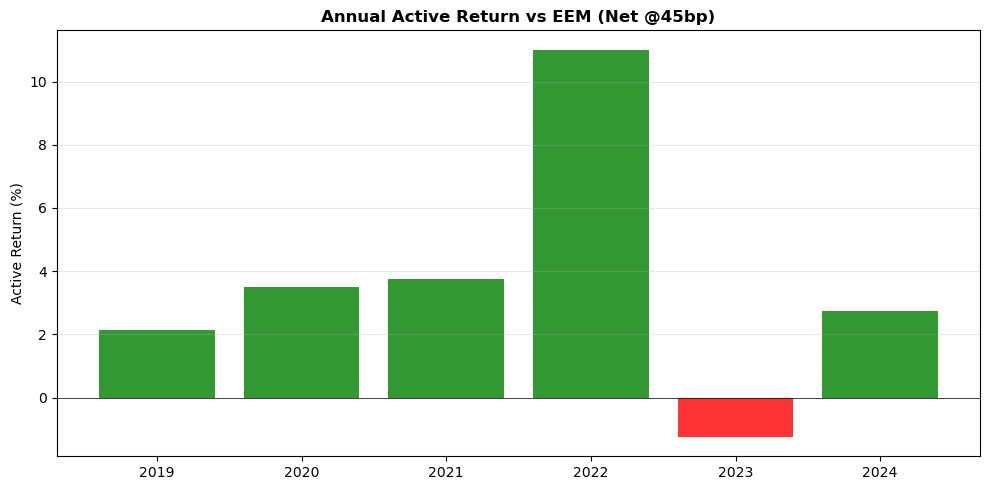

In [8]:
rows = []
for yr, g in excess_net.groupby(excess_net.index.year):
    eem_yr = eem_h.reindex(g.index).fillna(0)
    rows.append({
        'Year': yr,
        'Active Ret': (1+g).prod()-1,
        'Hit Rate': (g>0).mean(),
        'Sharpe': ann_sharpe(g + eem_yr),
        'TE': g.std()*np.sqrt(12),
        'IR': g.mean()*12/(g.std()*np.sqrt(12)) if g.std()>0 else np.nan,
        'N': int(len(g)),
    })
annual_active = pd.DataFrame(rows).set_index('Year')

print('ANNUAL ACTIVE RETURN ANALYSIS (Net @45bp)')
print('='*80)
print(annual_active.to_string(float_format=lambda x: f'{x:.3f}' if abs(x)<2 else f'{x:.0f}'))

n_positive_years = (annual_active['Active Ret'] > 0).sum()
n_years = len(annual_active)
print(f'\nConsistency: {n_positive_years}/{n_years} years with positive active return')
print(f'Best year:  {annual_active["Active Ret"].idxmax()} ({annual_active["Active Ret"].max():.1%})')
print(f'Worst year: {annual_active["Active Ret"].idxmin()} ({annual_active["Active Ret"].min():.1%})')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in annual_active['Active Ret']]
ax.bar(annual_active.index.astype(int), annual_active['Active Ret']*100, color=colors, alpha=0.8)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('Annual Active Return vs EEM (Net @45bp)', fontweight='bold')
ax.set_ylabel('Active Return (%)'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb08_annual_active.pdf', bbox_inches='tight')
plt.show()

## 8. Turnover Analysis

In [9]:
print('TURNOVER ANALYSIS: All6-EW + TO_MVO')
print('='*60)
print(f'  Stock selection TO:    {stock_to:.3f}/mo ({stock_to*12:.1f}x annual)')
print(f'  PC allocation TO:     {pc_to_mvo:.3f}/mo ({pc_to_mvo*12:.2f}x annual)')
print(f'  Total TO:              {total_to:.3f}/mo ({total_to*12:.1f}x annual)')
print(f'  TC drag @45bp:         {TC*12:.2%}/yr')

# TC impact at various levels
print(f'\n  TC SENSITIVITY:')
print(f'  {"TC":>6s} {"Net Sharpe":>10s} {"Net Return":>12s} {"Alpha vs EEM":>14s}')
for tc_bps in [0, 20, 30, 45, 60, 100]:
    drag = total_to * (tc_bps / 10000)
    net = s_h - drag
    net_sr = ann_sharpe(net)
    net_ret = ann_ret(net)
    alpha = net_ret - ann_ret(eem_h)
    print(f'  {tc_bps:>4d}bp {net_sr:10.3f} {net_ret:11.2%} {alpha:13.2%}')

TURNOVER ANALYSIS: All6-EW + TO_MVO
  Stock selection TO:    0.184/mo (2.2x annual)
  PC allocation TO:     0.007/mo (0.09x annual)
  Total TO:              0.192/mo (2.3x annual)
  TC drag @45bp:         1.03%/yr

  TC SENSITIVITY:
      TC Net Sharpe   Net Return   Alpha vs EEM
     0bp      0.607      11.50%         4.93%
    20bp      0.583      11.04%         4.47%
    30bp      0.571      10.81%         4.24%
    45bp      0.552      10.47%         3.89%
    60bp      0.534      10.12%         3.55%
   100bp      0.486       9.20%         2.63%


## 9. Return-Based Style Analysis (Sharpe 1992)

We decompose strategy returns using industry factor portfolios as style factors.
This follows Sharpe's (1992) framework where:
- **Style return** = weighted sum of factor portfolio returns
- **Selection return** = residual (alpha + noise)
- R² measures how much of the strategy is explained by style

RETURN-BASED STYLE ANALYSIS (Sharpe 1992)

  Style Weights (industry factor portfolios):
    BMATR : 9.1%
    CODIS : 9.1%
    COSTP : 9.1%
    ENEGY : 9.1%
    FINAN : 9.1%
    HLTHC : 9.1%
    INDUS : 9.1%
    RLEST : 9.1%
    TECNO : 9.1%
    TELCM : 9.1%
    UTILS : 9.1%

  R² (style):           0.939 (93.9% explained by style)
  Selection return (α):  1.87%/yr
  Selection vol:         4.64%
  Appraisal ratio:      0.402


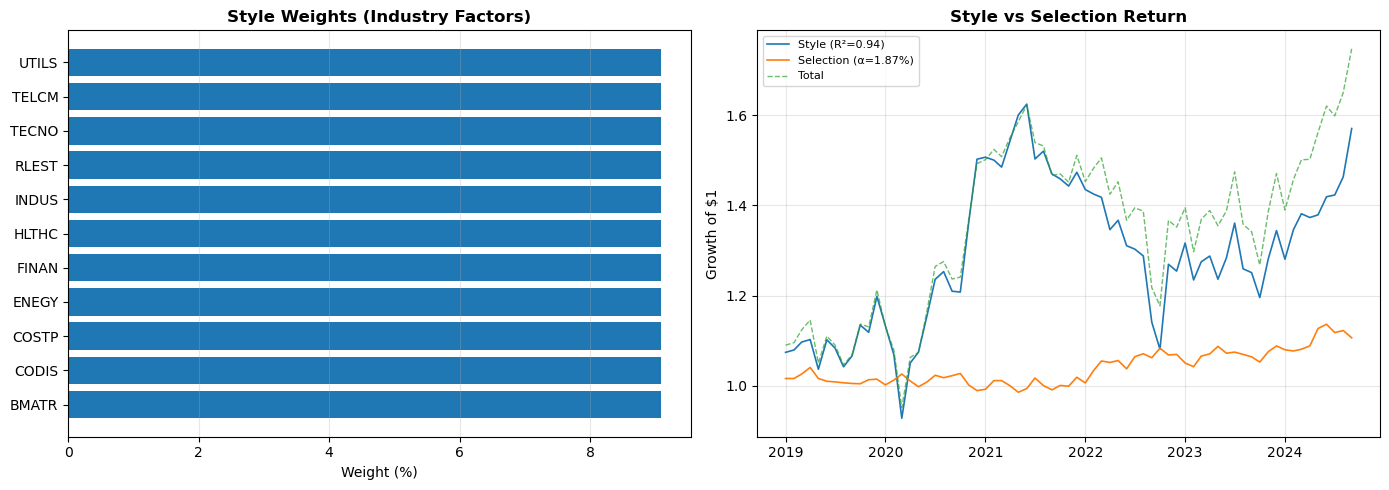


Saved weights to ../output/csv/nb08_to_mvo_weights.csv


In [10]:
# Align industry returns with strategy
ind_h = ind_ret.reindex(holdout).dropna(how='all')
common_dates = s_h.index.intersection(ind_h.index)
X = ind_h.loc[common_dates].values
y = s_h.loc[common_dates].values

# Constrained style analysis: weights sum to 1, non-negative
from scipy.optimize import minimize

def style_objective(w, X, y):
    residuals = y - X @ w
    return np.var(residuals)

n_assets = X.shape[1]
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds_style = [(0, 1)] * n_assets
w0 = np.ones(n_assets) / n_assets

result = minimize(style_objective, w0, args=(X, y), method='SLSQP',
                   bounds=bounds_style, constraints=constraints)
style_weights = result.x

# Compute style return and selection return
style_return = X @ style_weights
selection_return = y - style_return
alpha_style = np.mean(selection_return) * 12
r2_style = 1 - np.var(selection_return) / np.var(y)

print('RETURN-BASED STYLE ANALYSIS (Sharpe 1992)')
print('='*70)
print(f'\n  Style Weights (industry factor portfolios):')
for i, ind in enumerate(ind_h.columns):
    if style_weights[i] > 0.01:
        print(f'    {ind:6s}: {style_weights[i]:.1%}')

print(f'\n  R² (style):           {r2_style:.3f} ({r2_style*100:.1f}% explained by style)')
print(f'  Selection return (α):  {alpha_style:.2%}/yr')
print(f'  Selection vol:         {np.std(selection_return)*np.sqrt(12):.2%}')
print(f'  Appraisal ratio:      {alpha_style/(np.std(selection_return)*np.sqrt(12)):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
nonzero = [(ind_h.columns[i], style_weights[i]) for i in range(n_assets) if style_weights[i] > 0.005]
nonzero.sort(key=lambda x: x[1], reverse=True)
ax.barh([x[0] for x in nonzero], [x[1]*100 for x in nonzero])
ax.set_title('Style Weights (Industry Factors)', fontweight='bold')
ax.set_xlabel('Weight (%)'); ax.grid(True, alpha=0.3, axis='x')

ax = axes[1]
sel_series = pd.Series(selection_return, index=common_dates)
ax.plot((1 + pd.Series(style_return, index=common_dates)).cumprod(), lw=1.2, label=f'Style (R²={r2_style:.2f})')
ax.plot((1 + sel_series).cumprod(), lw=1.2, label=f'Selection (α={alpha_style:.2%})')
ax.plot((1 + s_h.loc[common_dates]).cumprod(), lw=1, ls='--', label='Total', alpha=0.7)
ax.set_title('Style vs Selection Return', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel('Growth of $1')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb08_style_analysis.pdf', bbox_inches='tight')
plt.show()

# Save
weights_df.to_csv(f'{OUTPUT_DIR}/csv/nb08_to_mvo_weights.csv')
print(f'\nSaved weights to {OUTPUT_DIR}/csv/nb08_to_mvo_weights.csv')

## Industry Portfolio Correlation


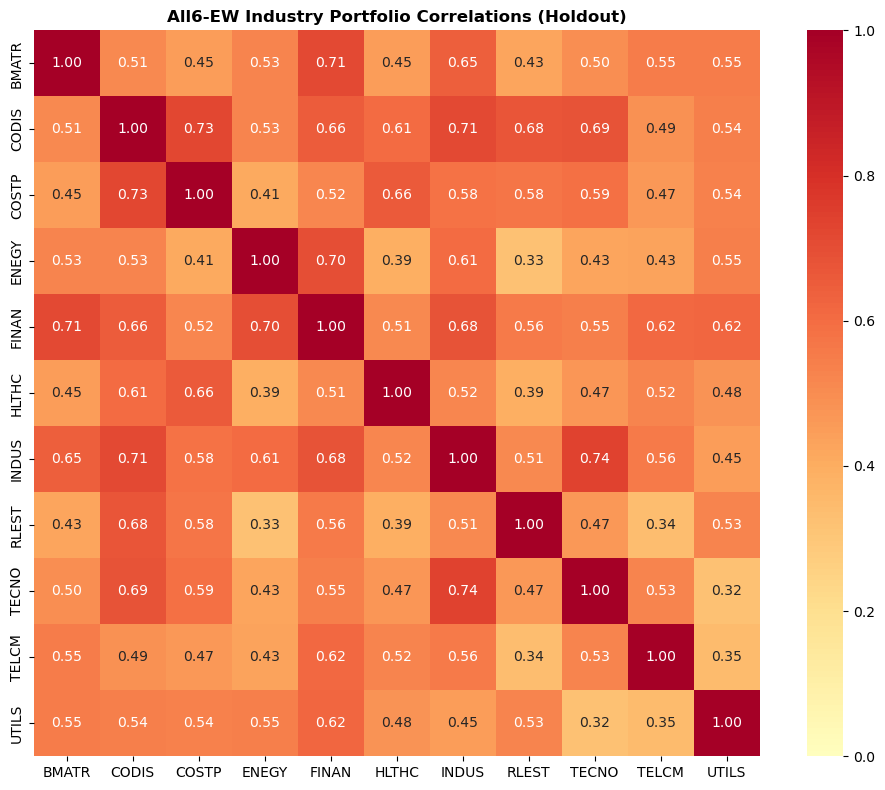

Average pairwise correlation: 0.535


In [11]:
# Industry factor portfolio correlation in holdout
ind_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/composite_all6_ew_industry_returns.csv', index_col=0, parse_dates=True)
ind_hold = ind_ret[ind_ret.index >= '2019-01']
corr = ind_hold.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            vmin=0, vmax=1, square=True, ax=ax)
ax.set_title('All6-EW Industry Portfolio Correlations (Holdout)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/nb08_industry_corr.pdf', bbox_inches='tight')
plt.show()
print(f'Average pairwise correlation: {corr.values[np.triu_indices(len(corr),1)].mean():.3f}')
